In [131]:
import numpy as np
import math
import matplotlib.pyplot as plt
import os
import pandas as pd

In [132]:
def lorentzian(x, x0, gamma, a):
    return (a / math.pi) * (gamma / ((x - x0) ** 2 + gamma ** 2))

def hypothesis(parameters, x):
    if isinstance(x, (list,np.ndarray)):
        y = np.empty((len(x)))
        for i in range(len(x)):
            output = 0
            for curve in parameters:
                output += lorentzian(x[i], curve[0], curve[1], curve[2])
            y[i] = output
        return y
    elif isinstance(x, float):
        output = 0
        for curve in parameters:
            output += lorentzian(x, curve[0], curve[1], curve[2])
        return output

In [133]:
def MSE_loss(x,y, parameters):
    assert len(x) == len(y)
    loss = np.array([0.5 * (hypothesis(parameters, x[i]) - y[i]) ** 2 for i in range(len(x))])
    return loss.sum()

In [134]:
def update(x,y,parameters, curve=-1,lr=0.0001):
    """Update parameters using gradient descent and MSE loss with one sample
    
    Parameters:
    x -- independent variable of data (usually first column of data, raman - (cm^-1), pl - (eV))
    y -- dependent variable of data (usually second column of data, intensity)
    parameters -- numpy array of parameters for curves used to fit data
    curve -- which curve to update; if left blank, update all
    lr -- sets how aggressively parameters are updated"""
    p_update = np.empty(parameters.shape)
    if curve == -1:
        for curve_ in range(len(parameters)):
            x0 = parameters[curve_][0]
            gamma = parameters[curve_][1]
            scaling = parameters[curve_][2]
            p_update[curve_][0] = lr * scaling * (2 * gamma) * (hypothesis(parameters, x) - y) * (x - x0) / (math.pi * ((x - x0) ** 2 + gamma ** 2) ** 2)
            p_update[curve_][1] = lr * scaling * ((1 / (math.pi * (gamma ** 2 + (x - x0) ** 2))) - ((2 * gamma ** 2) / (math.pi * (gamma ** 2 + (x - x0) ** 2) ** 2))) * (hypothesis(parameters, x) - y)
            p_update[curve_][2] = lr * (lorentzian(x, x0, gamma, scaling) / scaling) * (hypothesis(parameters, x) - y)
    else: 
        x0 = parameters[curve][0]
        gamma = parameters[curve][1]
        scaling = parameters[curve][2]
        p_update[curve][0] = lr * scaling * (2 * gamma) * (hypothesis(parameters, x) - y) * (x - x0) / (math.pi * ((x - x0) ** 2 + gamma ** 2) ** 2)
        p_update[curve][1] = lr * scaling * ((1 / (math.pi * (gamma ** 2 + (x - x0) ** 2))) - ((2 * gamma ** 2) / (math.pi * (gamma ** 2 + (x - x0) ** 2) ** 2))) * (hypothesis(parameters, x) - y)
        p_update[curve][2] = lr * (lorentzian(x, x0, gamma, scaling) / scaling) * (hypothesis(parameters, x) - y)
    parameters -= p_update
    return parameters

In [135]:
def batch_update(x, y, parameters, num_curves, lr=0.05):
    """Update parameters using batch gradient descent and MSE loss with all data
    
    Parameters:
    x -- list of independent variable of data (usually first column of data, raman - (cm^-1), pl - (eV))
    y -- list of dependent variable of data (usually second column of data, intensity)
    parameters -- numpy array of parameters for curves used to fit data
    lr -- sets how aggressively parameters are updated"""
    assert len(x) == len(y)
    for i in range(len(x)):
        # for j in range(len(parameters)):
        parameters = update(x[i], y[i], parameters, -1)
    return parameters

In [136]:
def graph_hypothesis(x, y, hypothesis=None, parameters=None, title=None):
    x_axis = np.linspace(x[0], x[-1])
    if hypothesis != None and parameters.all() != None:
        plt.plot(x, hypothesis(parameters,x), label="Lorentzian")
    plt.plot(x, y, label="Data")
    if title != None:
        plt.title(title)
    plt.show()

In [137]:
def get_peaks(data, n: int):
    assert isinstance(data, (list, np.ndarray))
    peaks = {}
    for i in range(1, len(data) - 1):
        if data[i] > data[i - 1] and data[i] > data[i + 1]:
            peaks[i] = data[i]
    highest_peaks = dict(sorted(peaks.items(), key=lambda x: x[1], reverse=True))
    return list(highest_peaks.keys())

In [138]:
x_axis = []

In [139]:
def init_parameters(file, num_curves: int, spectroscopy="raman"):   
    parameters = np.zeros((num_curves, 3))
    # with open("Jacky/Raman/MoS2_1_loc1_r.txt", encoding='latin-1') as f:
    with open(file, encoding='latin-1') as f:
        data = f.readlines()
        data = data[32:] # skip metadata
        data = [data[i].split() for i in range(len(data))]
        # try:
        x = [float(data[i][0]) for i in range(len(data))]
        y = [float(data[i][1]) - ((float(data[-1][1]) + float(data[0][1])) / 3)  if float(data[i][1]) - float(data[-1][1]) > 0 else 0 for i in range(len(data))] # subtracts baseline
        #     x_axis = x
        # except:
        #     print(data)
        #     x = x_axis
        #     y = [float(data[i][0]) - ((float(data[-1][0]) + float(data[0][0])) / 3)  if float(data[i][0]) - float(data[-1][0]) > 0 else 0 for i in range(len(data))] # subtracts baseline
        a = sorted(y, reverse=True)
        data_peaks = get_peaks(y, num_curves)
        try:
            for i in range(len(parameters)):
                parameters[i][0] = x[data_peaks[i]]
                parameters[i][1] = 10
                parameters[i][2] = a[0] * 10
        except:
            print(x)
    return parameters, np.array([x,y])

In [141]:
def get_data(file:str, spectroscopy: str):
    epochs = 3000
    num_curves = 0
    if spectroscopy == "raman":
        num_curves += 2
    elif spectroscopy == "pl":
        num_curves += 1
    parameters, raw_data = init_parameters(file, num_curves=2)
    print(parameters)
    if spectroscopy == "raman":
        data = np.split(raw_data, [len(raw_data // 2)], axis=1)
    else: 
        data = [raw_data]
    for _ in range(epochs):
        for i in range(len(data)):
            parameters = batch_update(data[i][0], data[i][1], parameters, num_curves=2)
    for i in range(num_curves):
        print(f'Loss for curve {i + 1} in {file} : {MSE_loss(data[i][0], data[i][1], parameters)}')
    print(parameters)
    graph_hypothesis(raw_data[0], raw_data[1], hypothesis, parameters, title = file)
    return parameters

In [142]:
def graph_txt(file):
    with open(file, encoding='latin-1') as f:
        data = f.readlines()
        data = data[32:] # skip metadata
        data = [data[i].split() for i in range(len(data))]
        x = [float(data[i][0]) for i in range(len(data))]
        y = [float(data[i][1]) for i in range(len(data))]
        plt.plot(x,y)
        plt.show()

In [143]:
def get_file_data(f):
    print(f)
    fit_parameters = get_data(f, spectroscopy="raman")
    peaks = [fit_parameters[i][0] for i in range(len(fit_parameters))]
    flip = False
    try:
        peak1, peak2 = peaks
    except:
        print("Wrong number of peaks")
    if peak1 > peak2:
        temp = peak2
        peak2 = peak1
        peak1 = temp
    intensities = hypothesis(fit_parameters, peaks)
    return peak1, peak2, intensities

In [150]:
def create_csv(folder, output_file):
    data = []
    # columns = ["Peak 1", "Peak 2", "Intensity 1", "Intensity 2"] if folder == "Raman" else ["Peak", "Intensity"]
    columns = ["File", "Peak 1", "Peak 2", "Intensity 1", "Intensity 2", "Peak Difference", "Intensity Difference"]
    if isinstance(folder, str):
        for filename in os.scandir("Jacky/" + folder):
            f = os.path.join("", filename)
            if f[-3:] != "txt":
                continue
            if os.path.isfile(f):
                peak1, peak2, intensities = get_file_data(f)
                data.append([f, peak1, peak2])
                data[-1].extend(intensities)
                data[-1].extend([abs(peak2 - peak1), abs(intensities[0] - intensities[1])])
    elif isinstance(folder, list):
        for sample in folder:
            for filename in os.scandir("Jacky/" + sample):
                f = os.path.join("", filename)
                if f[-3:] != "txt":
                    continue
                if os.path.isfile(f):
                    peak1, peak2, intensities = get_file_data(f)
                    data.append([f, peak1, peak2])
                    data[-1].extend(intensities)
                    data[-1].extend([abs(peak2 - peak1), abs(intensities[0] - intensities[1])])
    df = pd.DataFrame(data, columns=columns)
    df.to_csv(output_file, header=True)
    return df, data

In [147]:
sample_folder_num = [1,2,3,4,11,12,13,14]
sample_folder_list = [f"Shivani/Shivani Sample {sample_folder_num[i]}" for i in range(len(sample_folder_num))]

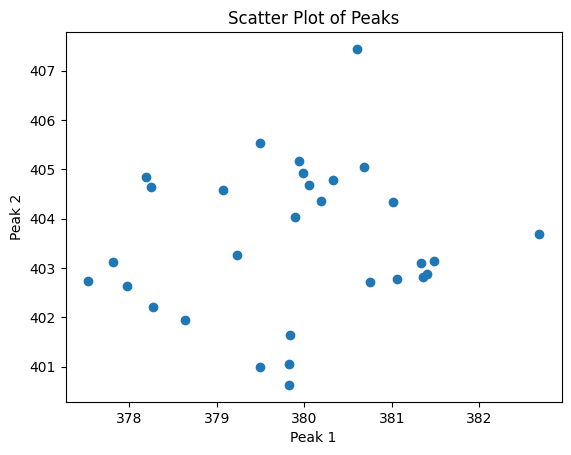

In [162]:
dummy_df = pd.read_csv("SampleRaman.csv")
p1 = dummy_df.loc[:34, "Peak 1"]
p2 = dummy_df.loc[:34, "Peak 2"]
peak1 = [p1[i] if p1[i] < 500 else None for i in range(len(p1))]
peak2 = [p2[i] if p2[i] < 500 else None for i in range(len(p2))]
plt.scatter(peak1, peak2)
plt.xlabel("Peak 1")
plt.ylabel("Peak 2")
plt.title("Scatter Plot of Peaks")
plt.show()

Jacky/Shivani/Shivani Sample 1/MoS2_3_loc4.txt
[[ 404.936    10.     2867.6611]
 [ 379.909    10.     2867.6611]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 1/MoS2_3_loc4.txt : 0.7686183816472572
Loss for curve 2 in Jacky/Shivani/Shivani Sample 1/MoS2_3_loc4.txt : 20544.70595259634
[[ 404.36553564    3.21447512 2865.97600052]
 [ 380.19376426    3.82289008 2863.04622339]]


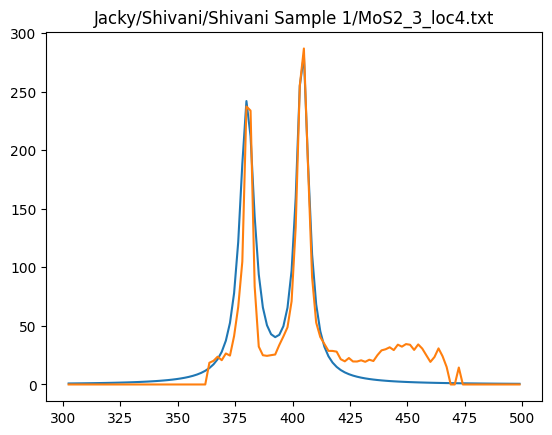

Jacky/Shivani/Shivani Sample 1/MoS2_3_loc5.txt
[[ 404.936        10.         2562.07373333]
 [ 381.701        10.         2562.07373333]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 1/MoS2_3_loc5.txt : 0.7119118022212421
Loss for curve 2 in Jacky/Shivani/Shivani Sample 1/MoS2_3_loc5.txt : 16783.811933409623
[[ 405.04926628    3.25072537 2560.04039105]
 [ 380.68216861    4.32354865 2558.10510766]]


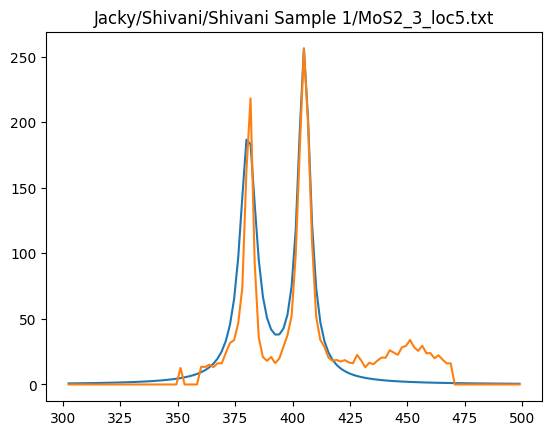

Jacky/Shivani/Shivani Sample 1/MoS2_2_loc2.txt
[[ 404.936        10.         3907.45663333]
 [ 381.701        10.         3907.45663333]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 1/MoS2_2_loc2.txt : 1.593922291451328
Loss for curve 2 in Jacky/Shivani/Shivani Sample 1/MoS2_2_loc2.txt : 39501.61528277273
[[4.04937204e+02 3.44694954e+00 3.90400549e+03]
 [3.79980805e+02 4.01365827e+00 3.90090917e+03]]


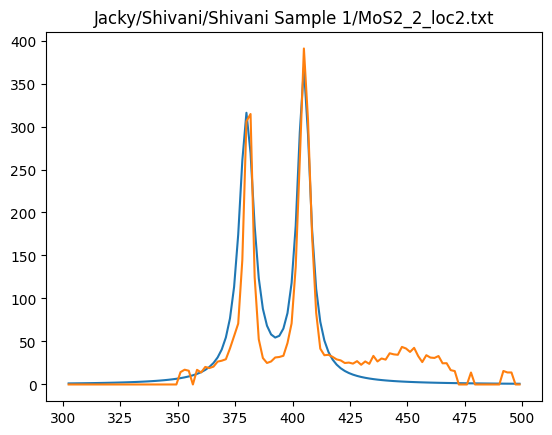

Jacky/Shivani/Shivani Sample 1/MoS2_3_loc2.txt
[[ 403.153        10.         1417.33736667]
 [ 381.701        10.         1417.33736667]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 1/MoS2_3_loc2.txt : 0.21974605351098314
Loss for curve 2 in Jacky/Shivani/Shivani Sample 1/MoS2_3_loc2.txt : 6196.354500792086
[[ 402.82554365    3.28110473 1416.37203918]
 [ 381.35153123    4.31887384 1415.5719206 ]]


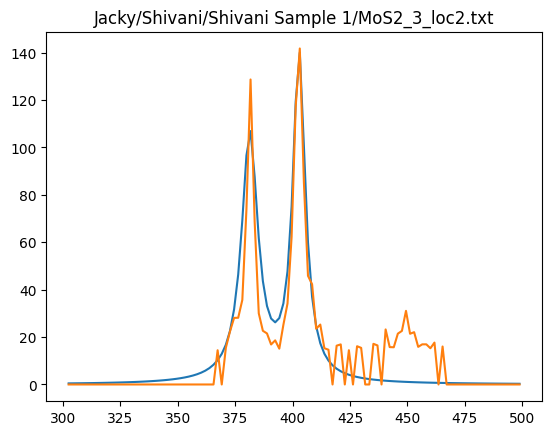

Jacky/Shivani/Shivani Sample 1/MoS2_3_loc3.txt
[[ 381.701        10.         1573.56566667]
 [ 401.367        10.         1573.56566667]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 1/MoS2_3_loc3.txt : 0.23290066213445312
Loss for curve 2 in Jacky/Shivani/Shivani Sample 1/MoS2_3_loc3.txt : 8936.934060374053
[[ 381.40622713    3.63582384 1571.18366519]
 [ 402.88934668    3.65068817 1572.87967147]]


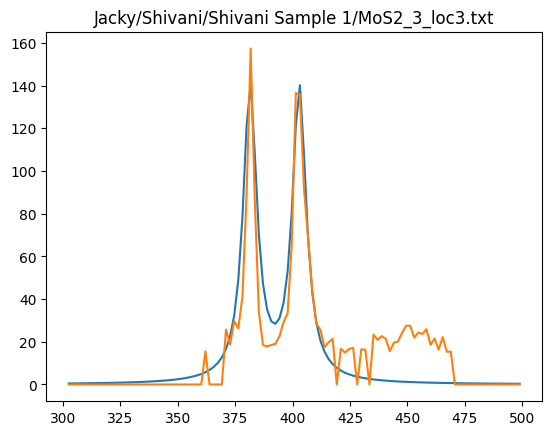

Jacky/Shivani/Shivani Sample 1/MoS2_2_loc3.txt
[302.471, 304.282, 306.093, 307.901, 309.712, 311.519, 313.329, 315.136, 316.943, 318.751, 320.557, 322.363, 324.168, 325.973, 327.777, 329.582, 331.385, 333.189, 334.992, 336.795, 338.595, 340.397, 342.197, 343.998, 345.797, 347.598, 349.396, 351.196, 352.994, 354.791, 356.588, 358.384, 360.181, 361.976, 363.772, 365.567, 367.362, 369.156, 370.948, 372.742, 374.535, 376.326, 378.119, 379.909, 381.701, 383.491, 385.28, 387.069, 388.859, 390.647, 392.435, 394.223, 396.01, 397.795, 399.581, 401.367, 403.153, 404.936, 406.721, 408.506, 410.288, 412.072, 413.854, 415.635, 417.418, 419.198, 420.979, 422.759, 424.538, 426.317, 428.096, 429.875, 431.653, 433.431, 435.206, 436.983, 438.758, 440.534, 442.308, 444.084, 445.857, 447.632, 449.405, 451.177, 452.949, 454.721, 456.492, 458.263, 460.034, 461.804, 463.574, 465.343, 467.111, 468.879, 470.646, 472.414, 474.18, 475.948, 477.713, 479.477, 481.244, 483.008, 484.772, 486.535, 488.298, 490.061, 4

/var/folders/08/551bq3_17bqcdv104sd7yclm0000gn/T/ipykernel_26513/2683149957.py:18: RuntimeWarning: invalid value encountered in scalar divide
  p_update[curve_][2] = lr * (lorentzian(x, x0, gamma, scaling) / scaling) * (hypothesis(parameters, x) - y)


Loss for curve 1 in Jacky/Shivani/Shivani Sample 1/MoS2_2_loc3.txt : nan
Loss for curve 2 in Jacky/Shivani/Shivani Sample 1/MoS2_2_loc3.txt : nan
[[nan nan nan]
 [nan nan nan]]


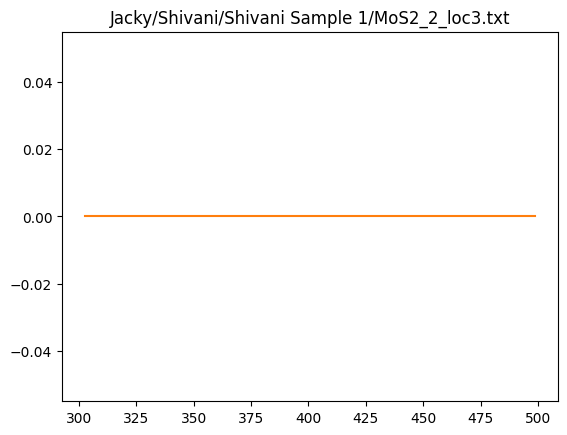

Jacky/Shivani/Shivani Sample 1/MoS2_2_loc1.txt
[[ 404.936    10.     4183.4224]
 [ 381.701    10.     4183.4224]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 1/MoS2_2_loc1.txt : 1.821253548162019
Loss for curve 2 in Jacky/Shivani/Shivani Sample 1/MoS2_2_loc1.txt : 44340.08479268939
[[4.05174582e+02 3.37815316e+00 4.18041061e+03]
 [3.79939647e+02 4.04734731e+00 4.17693378e+03]]


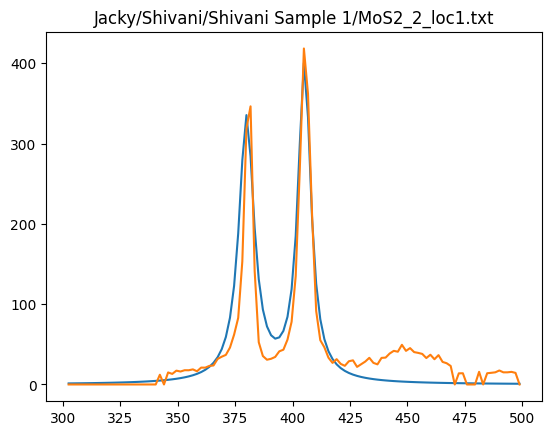

Jacky/Shivani/Shivani Sample 1/MoS2_4_loc2.txt
[[403.153       10.         668.28093333]
 [381.701       10.         668.28093333]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 1/MoS2_4_loc2.txt : 0.04909146378295396
Loss for curve 2 in Jacky/Shivani/Shivani Sample 1/MoS2_4_loc2.txt : 1569.8519833158146
[[402.7777088    3.095498   667.94440786]
 [381.05867738   4.41387936 667.41108991]]


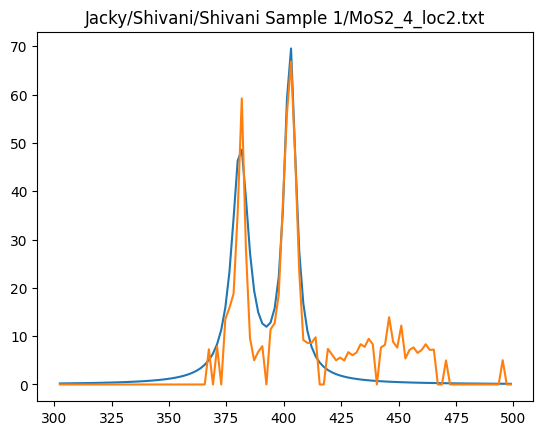

Jacky/Shivani/Shivani Sample 1/MoS2_4_loc3.txt
[[ 403.153        10.         2578.86683333]
 [ 379.909        10.         2578.86683333]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 1/MoS2_4_loc3.txt : 0.6240127138327464
Loss for curve 2 in Jacky/Shivani/Shivani Sample 1/MoS2_4_loc3.txt : 14411.77735378179
[[ 404.02704649    3.03489139 2577.07143296]
 [ 379.89380471    3.89546949 2575.07243573]]


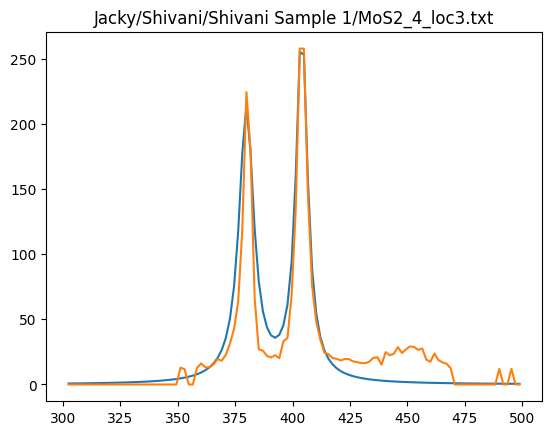

Jacky/Shivani/Shivani Sample 1/MoS2_4_loc1.txt
[[383.491       10.         321.28623333]
 [404.936       10.         321.28623333]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 1/MoS2_4_loc1.txt : 0.006363394969514426
Loss for curve 2 in Jacky/Shivani/Shivani Sample 1/MoS2_4_loc1.txt : 421.8885210462586
[[382.68439544   3.13778535 320.80852095]
 [403.68778991   2.84526216 320.93246696]]


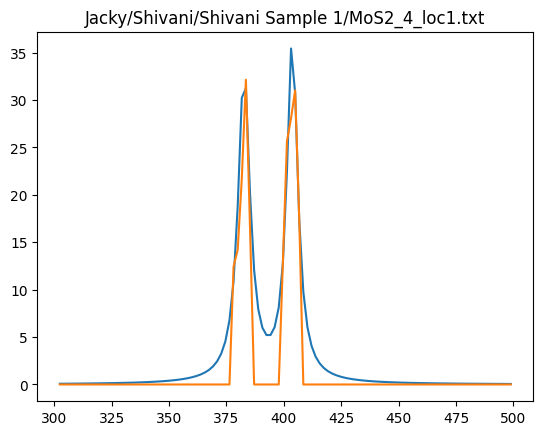

Jacky/Shivani/Shivani Sample 1/MoS2_4_loc4.txt
[[ 404.936        10.         3151.53066667]
 [ 379.909        10.         3151.53066667]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 1/MoS2_4_loc4.txt : 1.0723568756058572
Loss for curve 2 in Jacky/Shivani/Shivani Sample 1/MoS2_4_loc4.txt : 25220.813650574903
[[ 404.58219088    3.31338804 3147.61595842]
 [ 379.07472545    4.08126846 3145.92766008]]


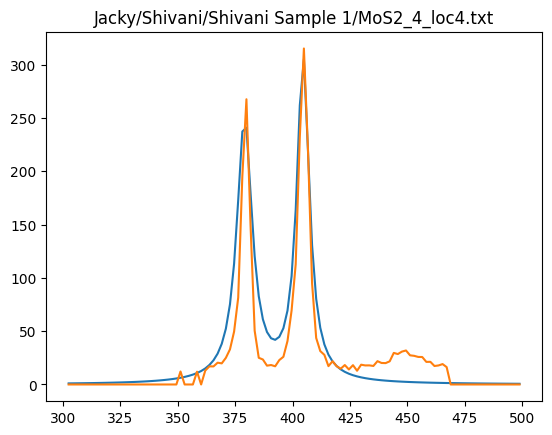

Jacky/Shivani/Shivani Sample 1/MoS2_4_loc5.txt
[[381.701       10.         892.13103333]
 [403.153       10.         892.13103333]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 1/MoS2_4_loc5.txt : 0.06376324393767721
Loss for curve 2 in Jacky/Shivani/Shivani Sample 1/MoS2_4_loc5.txt : 2182.14967820517
[[381.48100601   3.50614008 891.04023336]
 [403.13356696   3.14690401 891.85640748]]


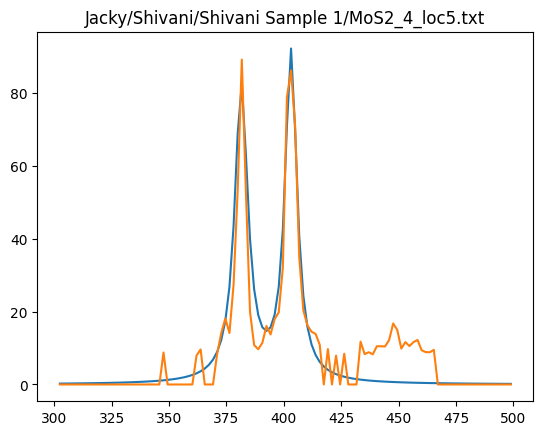

Jacky/Shivani/Shivani Sample 1/MoS2_1_loc1.txt
[[ 406.721        10.         5086.52863333]
 [ 379.909        10.         5086.52863333]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 1/MoS2_1_loc1.txt : 4.284096973452463
Loss for curve 2 in Jacky/Shivani/Shivani Sample 1/MoS2_1_loc1.txt : 382767.41377216775
[[1.11404685e+03 3.33536095e+02 5.08655756e+03]
 [3.79107851e+02 4.86282574e+00 5.08285112e+03]]


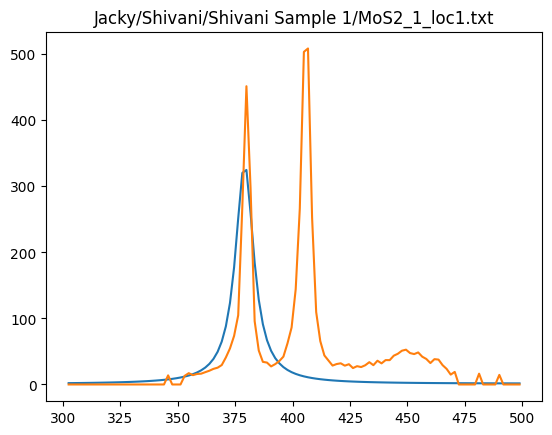

Jacky/Shivani/Shivani Sample 1/MoS2_1_loc2.txt
[[ 404.936    10.     2136.8625]
 [ 379.909    10.     2136.8625]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 1/MoS2_1_loc2.txt : 0.5402033903157273
Loss for curve 2 in Jacky/Shivani/Shivani Sample 1/MoS2_1_loc2.txt : 12417.39730447297
[[ 404.78375298    3.30240577 2134.38630231]
 [ 380.32537278    4.51941454 2133.63184958]]


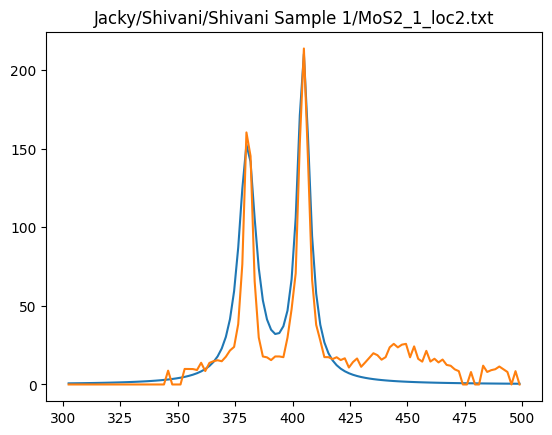

Jacky/Shivani/Shivani Sample 1/MoS2_1_loc3.txt
[[ 403.153        10.         1483.69033333]
 [ 381.701        10.         1483.69033333]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 1/MoS2_1_loc3.txt : 0.2490708115881854
Loss for curve 2 in Jacky/Shivani/Shivani Sample 1/MoS2_1_loc3.txt : 7233.478472482106
[[ 403.09300603    3.37328611 1482.34437007]
 [ 381.33345332    4.38019406 1481.80765904]]


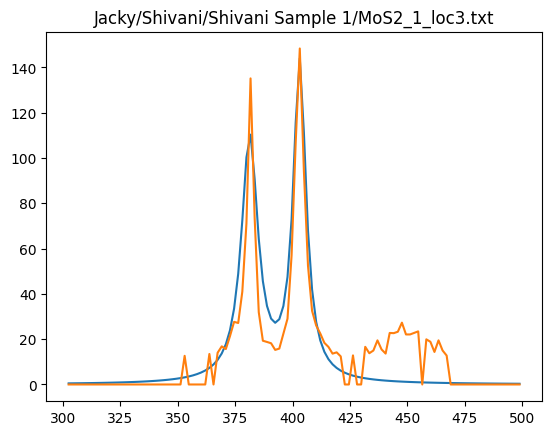

Jacky/Shivani/Shivani Sample 1/MoS2_1_loc6.txt
[[ 406.721    10.     3514.3775]
 [ 379.909    10.     3514.3775]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 1/MoS2_1_loc6.txt : 1.1911356702584452
Loss for curve 2 in Jacky/Shivani/Shivani Sample 1/MoS2_1_loc6.txt : 33494.89545660011
[[4.05544229e+02 3.14186160e+00 3.51084246e+03]
 [3.79492719e+02 3.92595601e+00 3.50811950e+03]]


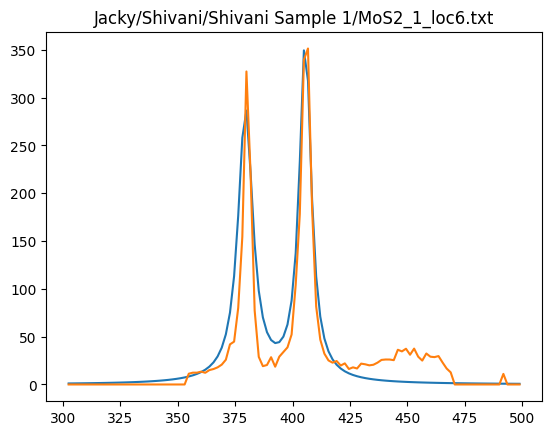

Jacky/Shivani/Shivani Sample 1/MoS2_1_loc4.txt
[[ 404.936        10.         3823.21973333]
 [ 381.701        10.         3823.21973333]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 1/MoS2_1_loc4.txt : 1.8740576308293961
Loss for curve 2 in Jacky/Shivani/Shivani Sample 1/MoS2_1_loc4.txt : 42491.26343082669
[[4.04682377e+02 3.55716237e+00 3.81881612e+03]
 [3.80055463e+02 4.60116257e+00 3.81682517e+03]]


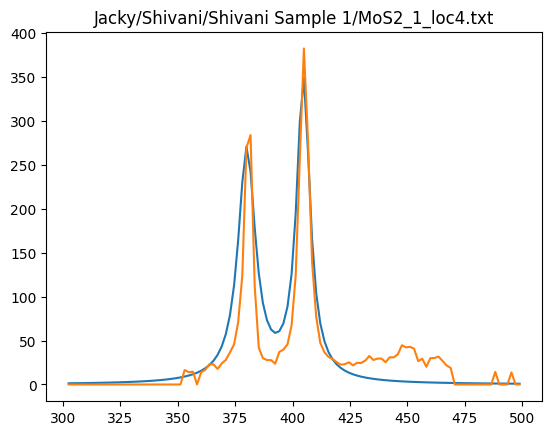

Jacky/Shivani/Shivani Sample 1/MoS2_1_loc5.txt
[[ 404.936        10.         2088.39363333]
 [ 381.701        10.         2088.39363333]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 1/MoS2_1_loc5.txt : 0.35596855238753355
Loss for curve 2 in Jacky/Shivani/Shivani Sample 1/MoS2_1_loc5.txt : 11492.391394680746
[[ 404.34219188    3.12628703 2087.88469116]
 [ 381.01016435    3.57277622 2085.37886186]]


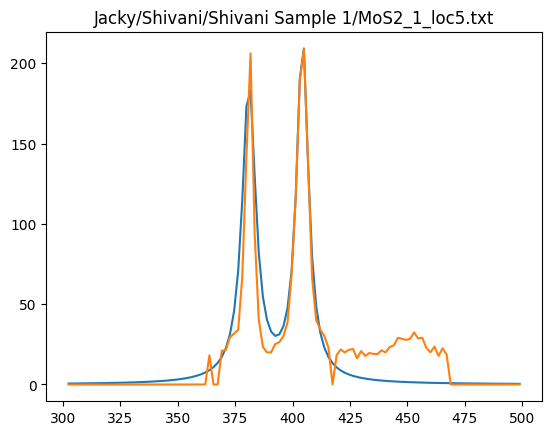

Jacky/Shivani/Shivani Sample 2/MoS2_1_loc1.txt
[[ 404.936        10.         4489.13736667]
 [ 379.909        10.         4489.13736667]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 2/MoS2_1_loc1.txt : 2.436966857923122
Loss for curve 2 in Jacky/Shivani/Shivani Sample 2/MoS2_1_loc1.txt : 50216.716233061954
[[4.04644491e+02 3.18432058e+00 4.48441936e+03]
 [3.78241952e+02 4.40473629e+00 4.48193429e+03]]


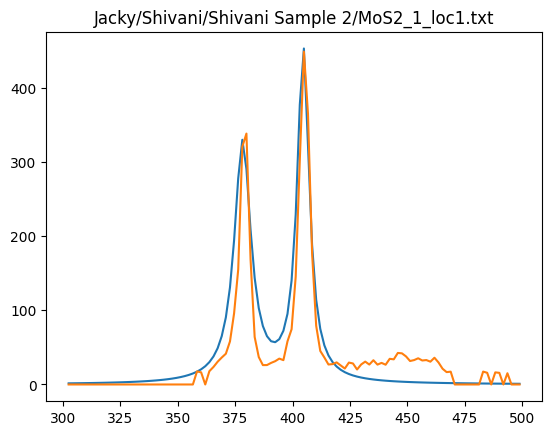

Jacky/Shivani/Shivani Sample 2/MoS2_1_loc2.txt
[[ 403.153        10.         1388.14816667]
 [ 381.701        10.         1388.14816667]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 2/MoS2_1_loc2.txt : 0.21690388406993633
Loss for curve 2 in Jacky/Shivani/Shivani Sample 2/MoS2_1_loc2.txt : 5011.862864742798
[[ 402.72259378    3.1538713  1387.0356589 ]
 [ 380.75513744    4.41767293 1386.23980194]]


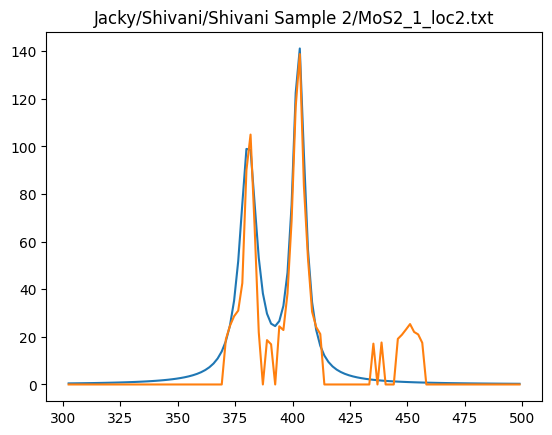

Jacky/Shivani/Shivani Sample 2/MoS2_1_loc3.txt
[[406.721       10.         664.82747667]
 [381.701       10.         664.82747667]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 2/MoS2_1_loc3.txt : 0.023385051314527935
Loss for curve 2 in Jacky/Shivani/Shivani Sample 2/MoS2_1_loc3.txt : 1663.3037925881968
[[407.44251925   2.87624737 663.74708279]
 [380.59673336   4.40278312 663.73754534]]


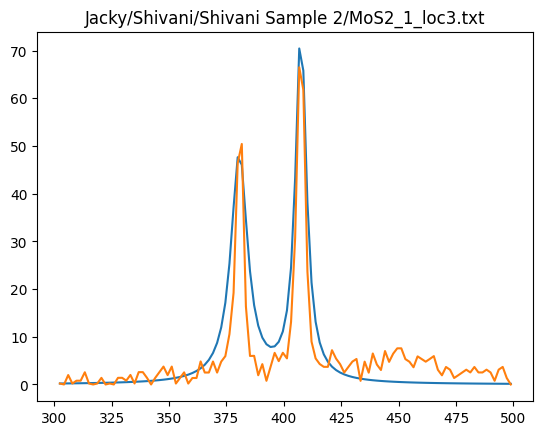

Jacky/Shivani/Shivani Sample 3/MoS2_1_loc8.txt
[[ 403.153   10.    1920.475]
 [ 378.119   10.    1920.475]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 3/MoS2_1_loc8.txt : 0.33783568040645773
Loss for curve 2 in Jacky/Shivani/Shivani Sample 3/MoS2_1_loc8.txt : 6643.3266075809615
[[ 402.64179749    3.27803776 1920.61565985]
 [ 377.96980343    3.44817847 1918.9109361 ]]


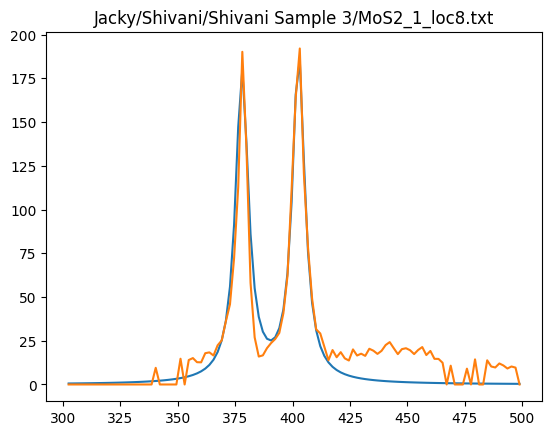

Jacky/Shivani/Shivani Sample 3/MoS2_1_loc1.txt
[[ 379.909    10.     1606.2894]
 [ 401.367    10.     1606.2894]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 3/MoS2_1_loc1.txt : 0.22330589362442085
Loss for curve 2 in Jacky/Shivani/Shivani Sample 3/MoS2_1_loc1.txt : 5535.320207881957
[[ 379.82765731    3.41558606 1604.62869897]
 [ 401.05959971    3.25785576 1606.34742989]]


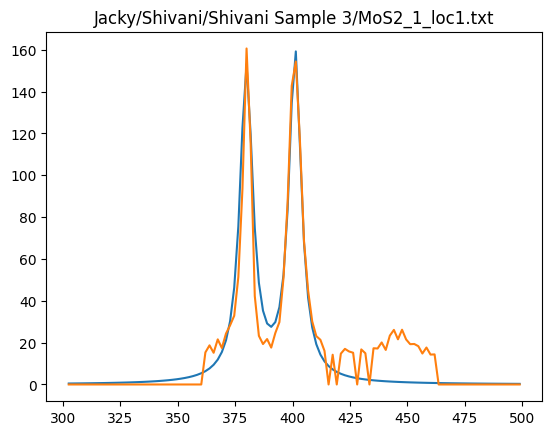

Jacky/Shivani/Shivani Sample 3/MoS2_1_loc2.txt
[[ 378.119        10.         1718.48183333]
 [ 401.367        10.         1718.48183333]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 3/MoS2_1_loc2.txt : 0.23335837483064747
Loss for curve 2 in Jacky/Shivani/Shivani Sample 3/MoS2_1_loc2.txt : 4641.291013030564
[[ 378.63543877    3.06182615 1717.00980239]
 [ 401.95444258    3.33929805 1719.05250706]]


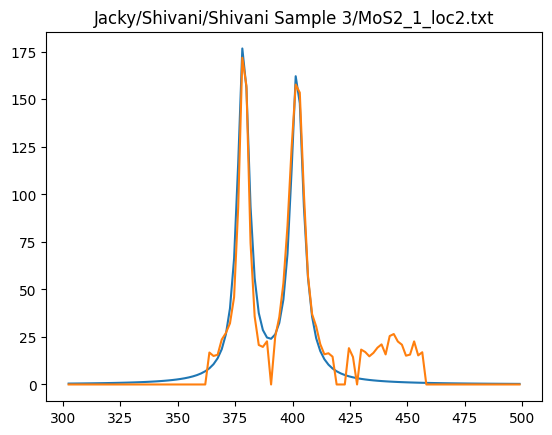

Jacky/Shivani/Shivani Sample 3/MoS2_1_loc3.txt
[[ 401.367        10.         2386.18486667]
 [ 378.119        10.         2386.18486667]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 3/MoS2_1_loc3.txt : 0.477573551602509
Loss for curve 2 in Jacky/Shivani/Shivani Sample 3/MoS2_1_loc3.txt : 9139.97635825536
[[ 402.22031647    3.02534309 2386.89774758]
 [ 378.26874686    3.37378913 2384.31537206]]


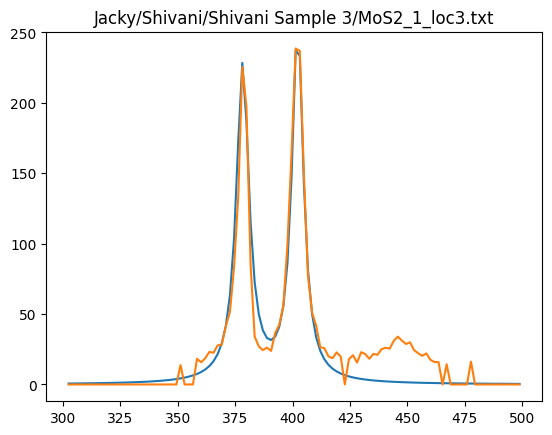

Jacky/Shivani/Shivani Sample 3/MoS2_1_loc7.txt
[[ 378.119    10.     3235.5424]
 [ 403.153    10.     3235.5424]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 3/MoS2_1_loc7.txt : 0.9559160536911331
Loss for curve 2 in Jacky/Shivani/Shivani Sample 3/MoS2_1_loc7.txt : 17694.045274914533
[[ 377.52913243    3.37789935 3231.35282109]
 [ 402.73055223    3.32696658 3233.79833759]]


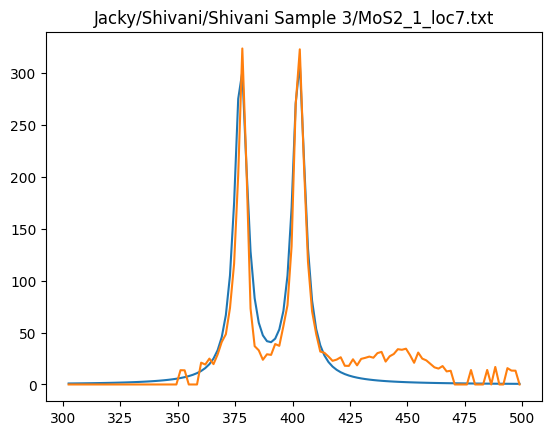

Jacky/Shivani/Shivani Sample 3/MoS2_1_loc6.txt
[[ 404.936        10.         1842.82939333]
 [ 378.119        10.         1842.82939333]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 3/MoS2_1_loc6.txt : 0.7824781309724771
Loss for curve 2 in Jacky/Shivani/Shivani Sample 3/MoS2_1_loc6.txt : 13691.517944179222
[[ 404.85558238    3.43211756 1838.92108676]
 [ 378.19180462    6.6392098  1839.63736761]]


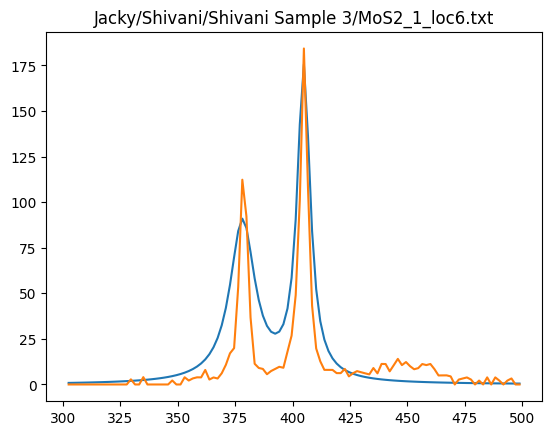

Jacky/Shivani/Shivani Sample 3/MoS2_1_loc4.txt
[[ 379.909        10.         1485.34626667]
 [ 399.581        10.         1485.34626667]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 3/MoS2_1_loc4.txt : 0.2156974327545732
Loss for curve 2 in Jacky/Shivani/Shivani Sample 3/MoS2_1_loc4.txt : 5370.937558765222
[[ 379.81962414    3.48621589 1483.35223438]
 [ 400.63145431    3.66865717 1484.77271101]]


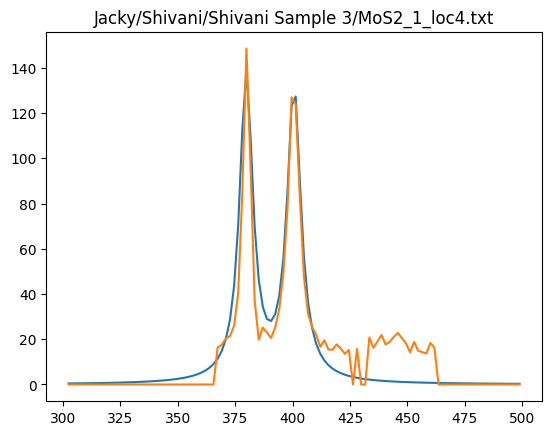

Jacky/Shivani/Shivani Sample 3/MoS2_1_loc5.txt
[[ 378.119        10.         3121.92916667]
 [ 403.153        10.         3121.92916667]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 3/MoS2_1_loc5.txt : 0.8838314971338934
Loss for curve 2 in Jacky/Shivani/Shivani Sample 3/MoS2_1_loc5.txt : 14954.431501517745
[[ 377.81749245    3.3109734  3118.40412897]
 [ 403.11811719    3.48403703 3122.31888482]]


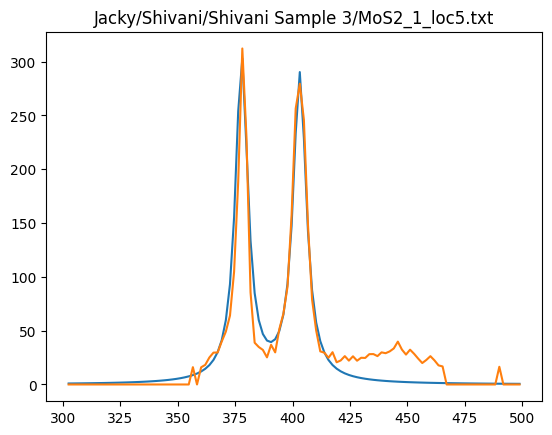

Jacky/Shivani/Shivani Sample 4/MoS2_1_loc1.txt
[[ 379.909        10.         1377.53603333]
 [ 401.367        10.         1377.53603333]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 4/MoS2_1_loc1.txt : 0.20317400664168764
Loss for curve 2 in Jacky/Shivani/Shivani Sample 4/MoS2_1_loc1.txt : 5266.297941724399
[[ 379.23069603    3.52895768 1375.71212355]
 [ 403.26310003    4.16000244 1377.41301478]]


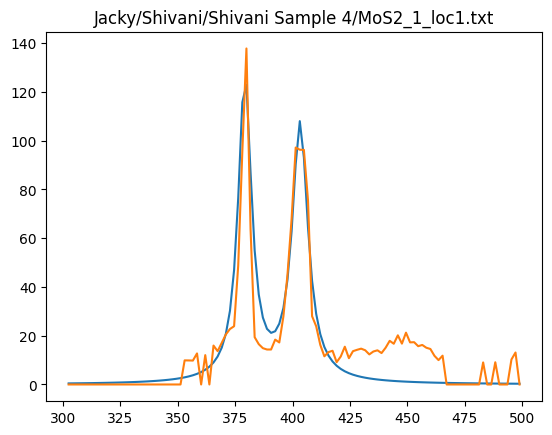

Jacky/Shivani/Shivani Sample 4/MoS2_1_loc2.txt
[[401.367       10.         905.19666667]
 [379.909       10.         905.19666667]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 4/MoS2_1_loc2.txt : 0.10681485957417311
Loss for curve 2 in Jacky/Shivani/Shivani Sample 4/MoS2_1_loc2.txt : 2495.775974987939
[[401.63733273   3.16229254 904.6973238 ]
 [379.84035284   4.73920376 904.20371773]]


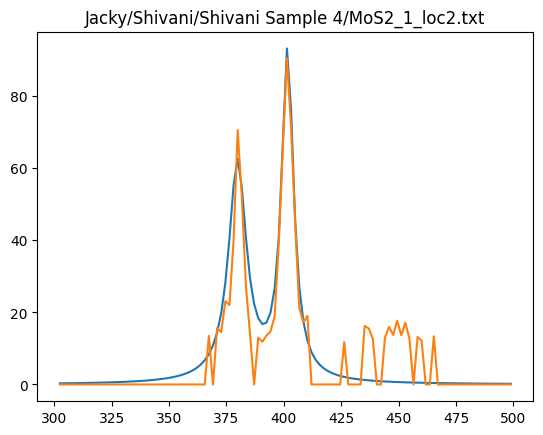

Jacky/Shivani/Shivani Sample 4/MoS2_1_loc3.txt
[[ 379.909        10.         1215.92773333]
 [ 401.367        10.         1215.92773333]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 4/MoS2_1_loc3.txt : 0.13163910422553693
Loss for curve 2 in Jacky/Shivani/Shivani Sample 4/MoS2_1_loc3.txt : 4474.530099187685
[[ 379.49585487    3.53432273 1213.62997998]
 [ 400.99399568    3.14418591 1214.91169606]]


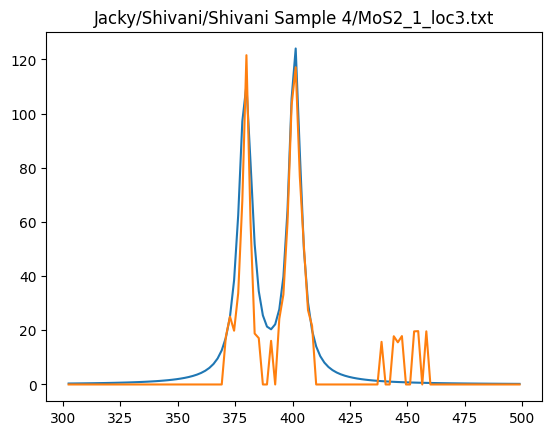

Jacky/Shivani/Shivani Sample 11/FeMoS2_2_loc2.txt
[[516.596  10.    780.82 ]
 [401.768  10.    780.82 ]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 11/FeMoS2_2_loc2.txt : 0.0007354962312726197
Loss for curve 2 in Jacky/Shivani/Shivani Sample 11/FeMoS2_2_loc2.txt : 4742.293714724383
[[517.07872527   3.47004233 782.63338985]
 [401.63705304   7.86647311 780.12434034]]


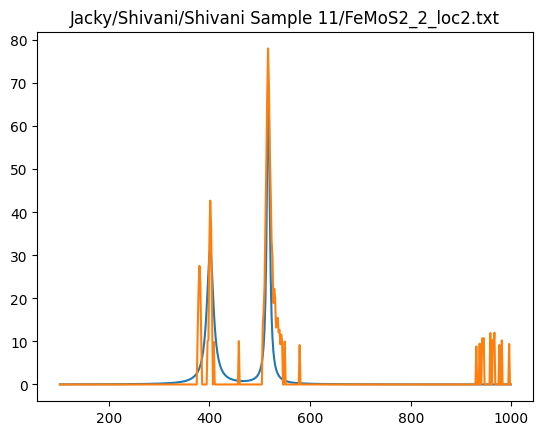

Jacky/Shivani/Shivani Sample 11/FeMoS2_2_loc1.txt
[[ 516.596        10.         1045.02443333]
 [ 401.768        10.         1045.02443333]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 11/FeMoS2_2_loc1.txt : 0.003339198565478369
Loss for curve 2 in Jacky/Shivani/Shivani Sample 11/FeMoS2_2_loc1.txt : 13272.393138891053
[[ 517.23201576    3.42835117 1047.32145328]
 [ 399.78330589   13.45491576 1045.01396006]]


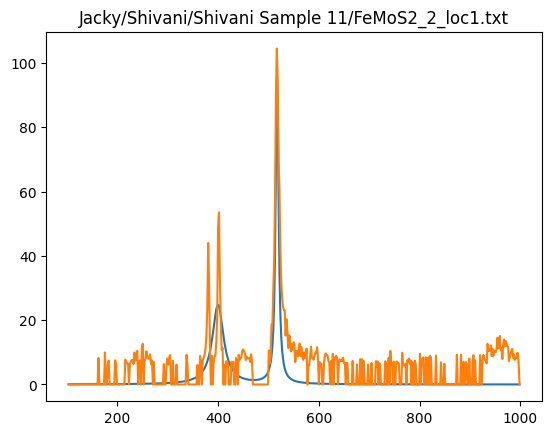

Jacky/Shivani/Shivani Sample 11/FeMoS2_1_loc1.txt
[[ 403.549        10.         1188.77016667]
 [ 516.596        10.         1188.77016667]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 11/FeMoS2_1_loc1.txt : 0.0005735033857163204
Loss for curve 2 in Jacky/Shivani/Shivani Sample 11/FeMoS2_1_loc1.txt : 27410.850960525193
[[ 403.28157991    3.48652616 1188.79185037]
 [ 517.40134959    4.15108683 1190.64834854]]


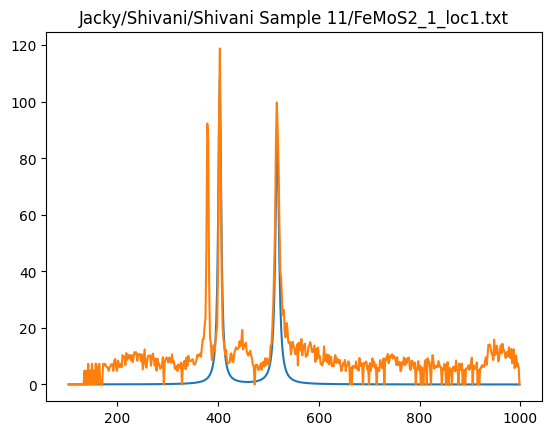

Jacky/Shivani/Shivani Sample 11/FeMoS2_1_loc2.txt
[[518.348   10.     750.7632]
 [403.549   10.     750.7632]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 11/FeMoS2_1_loc2.txt : 0.00032050923678983033
Loss for curve 2 in Jacky/Shivani/Shivani Sample 11/FeMoS2_1_loc2.txt : 6418.161196527719
[[517.70386062   3.35982899 752.51227357]
 [402.32446469   4.91570674 750.34103821]]


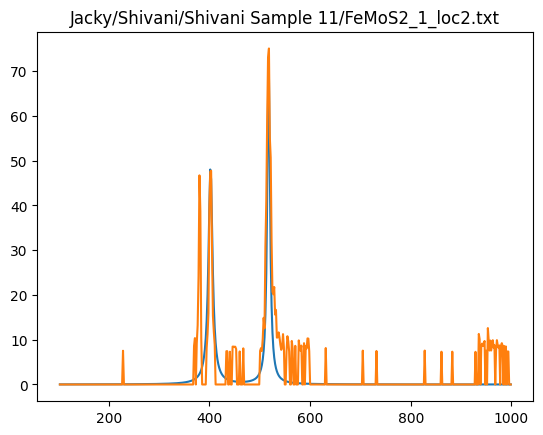

Jacky/Shivani/Shivani Sample 12/FeMoS2_1_loc1.txt
[[516.596       10.         878.13503333]
 [401.768       10.         878.13503333]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 12/FeMoS2_1_loc1.txt : 0.0006522644658681122
Loss for curve 2 in Jacky/Shivani/Shivani Sample 12/FeMoS2_1_loc1.txt : 11778.21682371711
[[517.18160088   3.5619006  880.43553333]
 [401.06136943   6.21622828 877.84800956]]


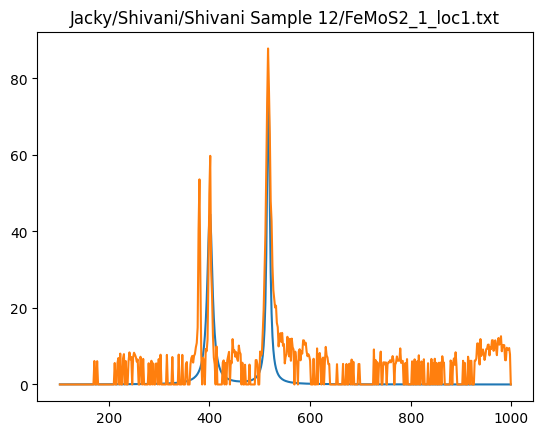

Jacky/Shivani/Shivani Sample 12/FeMoS2_1_loc2.txt
[[518.348   10.     811.9981]
 [401.768   10.     811.9981]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 12/FeMoS2_1_loc2.txt : 0.00036526056696555915
Loss for curve 2 in Jacky/Shivani/Shivani Sample 12/FeMoS2_1_loc2.txt : 10909.05787128871
[[517.58993787   3.40537687 814.68525499]
 [401.24208319   4.7702108  811.14379372]]


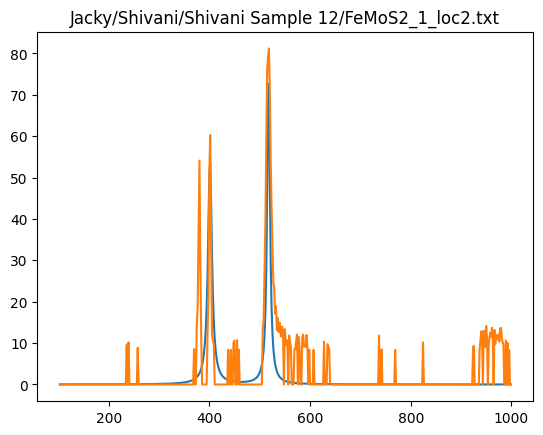

Jacky/Shivani/Shivani Sample 13/FeMoS2_1_loc1.txt
[[ 518.348    10.     2968.4094]
 [ 401.768    10.     2968.4094]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 13/FeMoS2_1_loc1.txt : 0.031902090351463894
Loss for curve 2 in Jacky/Shivani/Shivani Sample 13/FeMoS2_1_loc1.txt : 110370.82039799547
[[ 519.79780896    3.58206086 2977.53197753]
 [ 400.23567441   14.78362882 2969.63725522]]


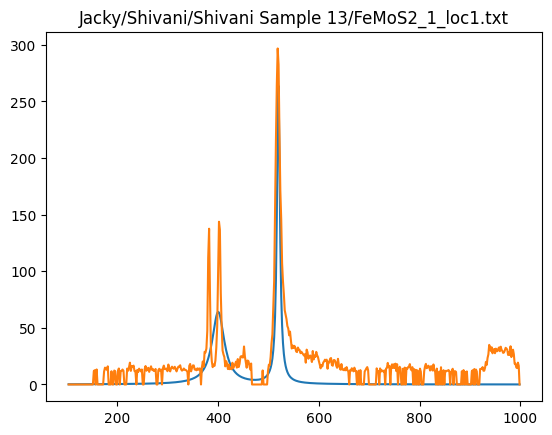

Jacky/Shivani/Shivani Sample 13/FeMoS2_1_loc2.txt
[[ 518.348    10.     3677.1242]
 [ 403.549    10.     3677.1242]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 13/FeMoS2_1_loc2.txt : 0.02285981793033509
Loss for curve 2 in Jacky/Shivani/Shivani Sample 13/FeMoS2_1_loc2.txt : 159109.1674994562
[[5.20510273e+02 3.65474331e+00 3.68816324e+03]
 [4.01950288e+02 9.59351135e+00 3.67714390e+03]]


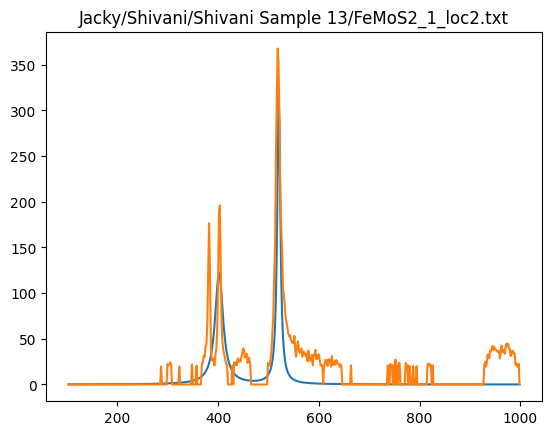

Jacky/Shivani/Shivani Sample 14/FeMoS2_1_loc1.txt
[[ 405.33         10.         6683.31366667]
 [ 380.35         10.         6683.31366667]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 14/FeMoS2_1_loc1.txt : 0.039149803779871
Loss for curve 2 in Jacky/Shivani/Shivani Sample 14/FeMoS2_1_loc1.txt : 462880.6858661638
[[4.04204663e+02 3.61896632e+00 6.68185881e+03]
 [3.78199708e+02 3.97494020e+00 6.67538833e+03]]


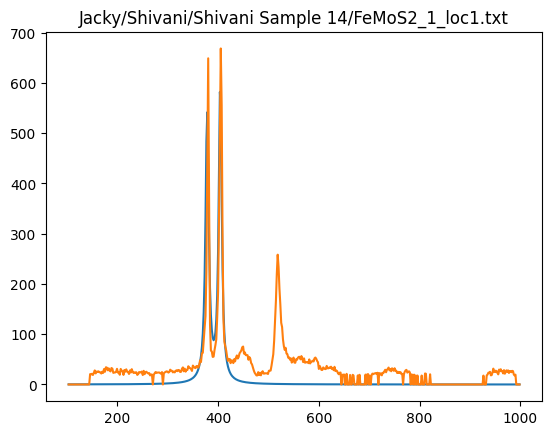

Jacky/Shivani/Shivani Sample 14/FeMoS2_1_loc2.txt
[[ 520.098        10.         3593.09373333]
 [ 405.33         10.         3593.09373333]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 14/FeMoS2_1_loc2.txt : 0.005929531479370932
Loss for curve 2 in Jacky/Shivani/Shivani Sample 14/FeMoS2_1_loc2.txt : 287912.78944679885
[[ 520.74418147    3.75161433 3605.82298332]
 [ 404.60607466    4.12082257 3594.08090435]]


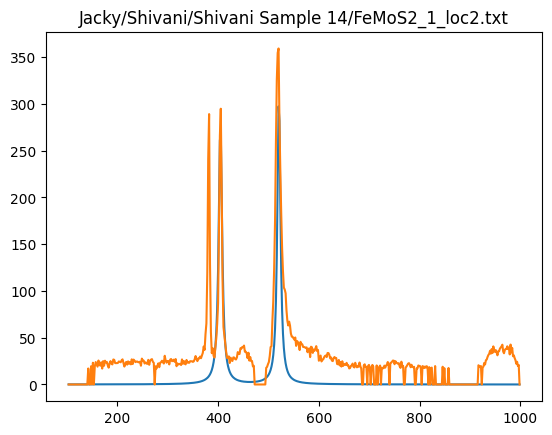

Jacky/Shivani/Shivani Sample 14/FeMoS2_1_loc3.txt
[[ 405.33         10.         4938.86206667]
 [ 380.35         10.         4938.86206667]]
Loss for curve 1 in Jacky/Shivani/Shivani Sample 14/FeMoS2_1_loc3.txt : 0.03232051698850402
Loss for curve 2 in Jacky/Shivani/Shivani Sample 14/FeMoS2_1_loc3.txt : 128119.26773458629
[[4.05151433e+02 4.46185280e+00 4.93468395e+03]
 [3.78409781e+02 4.91398830e+00 4.93017216e+03]]


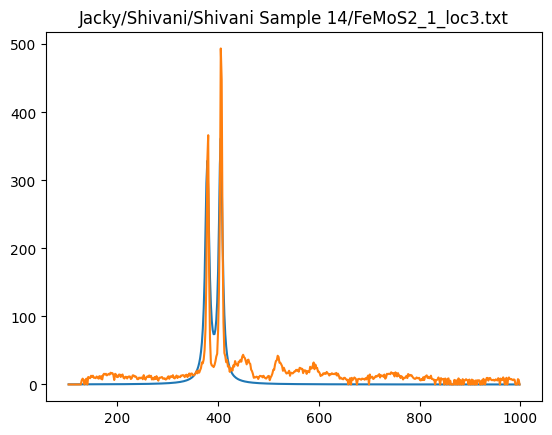

In [151]:
sample_df, _ = create_csv(sample_folder_list, "SampleRaman.txt")